#**1. OPIS PROBLEMA:**

Najprije je važno detaljno objasniti samu problematiku. Dakle, procjena kreditne sposobnosti jedan je od najvažnijih zadataka u bankarskom sektoru. Kreditna sposobnost odnosi se na sposobnost klijenta da redovno vraća posuđeni novac. U širem smislu predstavlja mjeru kreditnog rizika povezanog sa određenim klijentom. Banke i druge finansijske institucije koriste procjenu kreditne sposobnosti kako bi odlučile hoće li odobriti kredit te pod kojim uslovima će ga odobriti. Za procjenu kreditne sposobnosti potrebno je prikupiti i analizirati relevantne podatke, s ciljem određivanja vjerovatnoće da će klijent otplatiti kredit, zajedno sa kamatama, u predviđenom roku.

Međutim, svaka banka zasebno definiše kriterije na osnovu kojih procjenjuje kreditnu sposobnost klijenta. Tradicionalni modeli odlučivanja zasnivaju se na strogo definisanim kriterijima i granicama, poput minimalnog prihoda ili maksimalnog dozvoljenog nivoa zaduženosti. Ovakav pristup često ne uzima u obzir realne nijanse i razlike među klijentima. Na primjer, dva klijenta mogu imati sličan kreditni rejting, ali da se razlikuju po stabilnosti zaposlenja, količini ušteđenog novca ili urednosti otplate prethodnih dugova. U takvim slučajevima, klasični modeli koji koriste binarne odluke (da/ne) mogu biti nedovoljno precizni i neprilagođeni stvarnim uslovima.

Upravo u takvim situacijama fuzzy logika pokazuje svoju prednost. Umjesto donošenja striktnih binarnih odluka, fuzzy logika omogućava procjenu kreditne sposobnosti na osnovu neizrazitih/nepreciznih (fuzzy) varijabli/parametara. Fuzzy logika koristi fuzzy skupove koji omogućavaju postojanje različitih stepena pripadnosti. Na primjer, plata može biti istovremeno ocjenjena kao "srednja" sa stepenom pripanosti 0.6 i "visoka" sa 0.4. Pored toga, fuzzy logika se oslanja na skup pravila koji podsjeća na ljudsko rezonovanje i razmišljanje. Na osnovu takvih pravila i odgovarajućih izračuna, moguće je donijeti fleksibilniju procjenu kreditne sposobnosti datog klijenta.

U nastavku rada biti će detaljno prikazan svaki korak u procesu procjene kreditne sposobnosti koristeći fuzzy logiku.

Izvori:

https://moj-bankar.ba/view-more/sta-znaci-kreditna-nbsp-sposobnost/96

https://financijskapocetnica.rba.hr/blog/kreditna-sposobnost/

https://moj-bankar.ba/view-more/sta-znaci-kreditna-nbsp-sposobnost/96

#**2. DEFINICIJA ULAZNIH I IZLAZNIH VARIJABLI:**

###**Ulazne varijable:**
**1.Odnos duga i prihoda (DTI ratio)**

Predstavlja procenat mjesečnog prihoda koji ide na otplatu rate (duga) kredita.

**2. Visina prihoda**

Predstavlja mjesečna ili godišnja primanja klijenta.

**3. Stabilnost zaposlenja**

Da li klijent radi na određeno ili neodređeno, u principu to je broj godina ili mjeseci provedenih na trenutnom radnom mjestu.

**4. Učestalost kašnjenja sa otplatom**

Predstavlja broj koliko je učestalo klijent kasnio sa otplatom kredita u prethodnom periodu.

**5. Štednja**

Predstavlja količinu (iznos) novca u raspoloživoj štednji.

**6. Broj aktivnih kredita**

Predstavlja ukupan broj kredita koje klijent trenutno otplaćuje.

**7. Dužina kreditne historije**

Predstavlja brojčano koliko dugo vremenski klijent koristi kreditne proizvode.

###**Izlazne varijable:**

1. Kreditna sposobnost

Izražena pomoću FICO skale (od 300 d0 850).

#**3. DEFINISANJE I IMPLEMENTIRANJE FUZZY SKUPOVA:**

Uključivanje Phyton biblioteka: numpy, skfuzzy.

In [ ]:
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 7.8 MB/s eta 0:00:00


###1. Odnos duga i prihoda (DTI ratio):

Definicija DTI ratio:

DTI(%) = (Mjesečna otplata duga / Mjesečni prihod) * 100.

Dakle, što je niži DTI ratio, to je klijent kreditno sposobniji.

Izražavanjem procenutalno imamo sljedeće dodjele:
1. Vrlo nisko opterećenje (nizak): 0% - 35% => tip funkcije: trapez
3. Povećani rizici (srednji): 30% - 50% => tip funkcije: trougao
3. Kritično (visok): 45% - 100% => tip funkcije: trapez

Izvor:

https://www.wellsfargo.com/goals-credit/smarter-credit/credit-101/debt-to-income-ratio/understanding-dti/

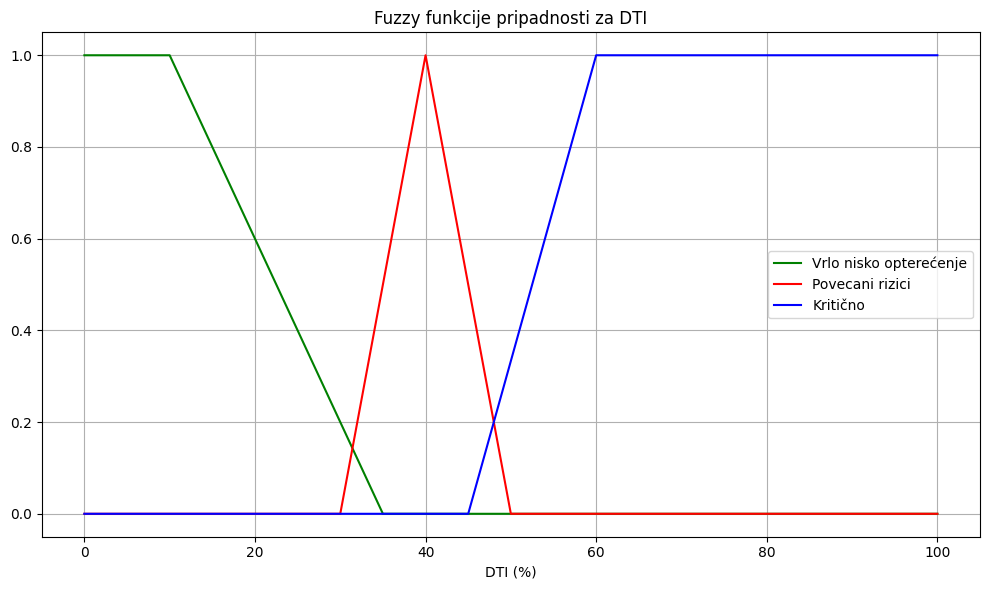

In [ ]:
#Univerzum DTI: 0% do 100%
dti = ctrl.Antecedent(np.arange(0, 101, 1), 'dti_ratio')

#Funkcije pripadnosti
dti['vrlo_nizak'] = fuzz.trapmf(dti.universe, [0, 0, 10, 35])
dti['povecani_rizici'] = fuzz.trimf(dti.universe, [30, 40, 50])
dti['kriticno'] = fuzz.trapmf(dti.universe, [45, 60, 100, 100])

# Prikaz grafa
plt.figure(figsize=(10, 6))
plt.plot(dti.universe, dti['vrlo_nizak'].mf, label='Vrlo nisko opterećenje', color='green')
plt.plot(dti.universe, dti['povecani_rizici'].mf, label='Povecani rizici', color='red')
plt.plot(dti.universe, dti['kriticno'].mf, label='Kritično', color='blue')
plt.title('Fuzzy funkcije pripadnosti za DTI')
plt.xlabel('DTI (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###2. Visina prihoda:

Na osnovu dostupnih podataka prosječna bruto plata u FBiH (podatak iz januara 2025. godine) iznosi 2.414 KM. Dok u RS-u iznosi 2.194 KM, a u Brčko distriktu (podatak iz decembra 2024. godine) iznosi 2.047,60 KM. Kada sve sumiramo prosječna plata u BiH (podatak iz januara 2025. godine) iznosi 2.338 KM.

Kada govorimo o najnižoj plati imamo sljedeće podatke. U FBiH minimalna plata iznosi oko 560 KM neto. U Republici Srpskoj minimalna plata je nešto niža, oko 520 KM neto. U Brčko distriktu minimalna plata varira, ali je obično blizu minimalca u entitetima. U skladu sa svime prethodno rečenim minimalna bruto plata je veća zbog doprinosa i poreza, pa je oko 800-900 KM bruto.

Najveće plate u BiH su uglavnom u privatnom sektoru, IT industriji, menadžmentu i u još nekim stručnim zanimanjima. Takve plate mogu dostići i preko 5.000 KM neto, a bruto i znatno više. Statistički najvišu platu prima mendžer ili direktor IT kompanije, koja iznosi oko 4.974 KM neto. Međutim, neki IT stručnjaci na senior poziciji mogu dostići platu i od čak 7.000 KM neto.

Izvori:

https://www.plata.ba/plata/visi-menadzment

https://biznis.ba/pauza/ovo-su-neke-od-najboljih-i-najgorih-placenih-pozicija-u-bih/89579

https://www.stat.gov.rs/sr-latn/oblasti/trziste-rada/zarade


https://fzs.ba/

U skladu sa svim ovim informacijama ćemo formirati fuzzy funkcije pripadnosti.

1. Niska plata: <1.200 KM => tip funkcije: trapez
2. Srednja plata: između 1000 i 3.600 KM => tip funkcije: trougao
3. Visoka plata: >3.200 KM => tip funkcije: trapez

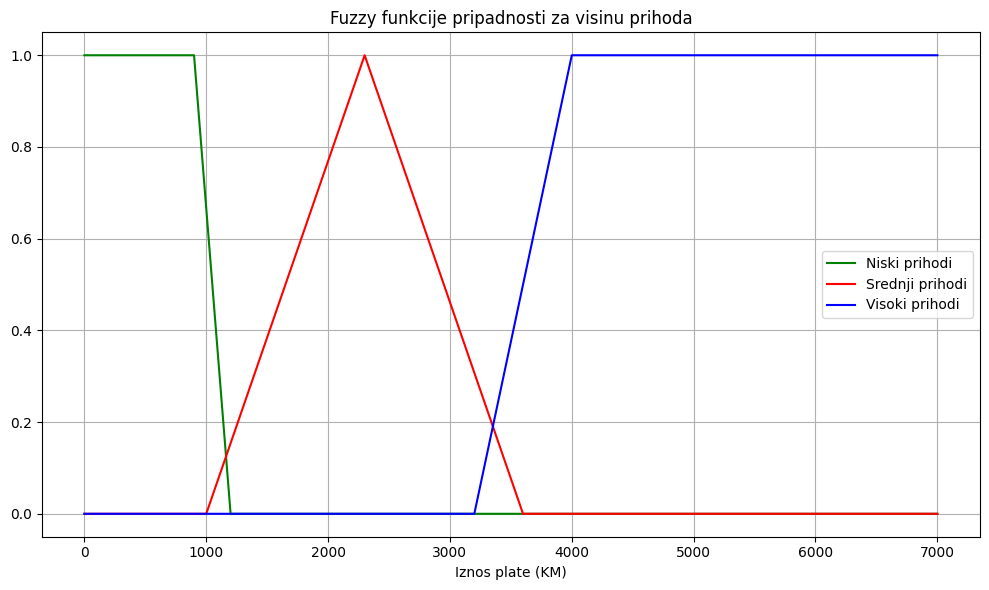

In [ ]:
#Univerzum prihoda: 0 - 7.000
prihodi = ctrl.Antecedent(np.arange(0, 7001, 1), 'prihodi')

#Funkcije pripadnosti
prihodi['niska'] = fuzz.trapmf(prihodi.universe, [0, 0, 900, 1200])
prihodi['srednja'] = fuzz.trimf(prihodi.universe, [1000, 2300, 3600])
prihodi['visoka'] = fuzz.trapmf(prihodi.universe, [3200, 4000, 7000, 7000])

# Prikaz grafa
plt.figure(figsize=(10, 6))
plt.plot(prihodi.universe, prihodi['niska'].mf, label='Niski prihodi', color='green')
plt.plot(prihodi.universe, prihodi['srednja'].mf, label='Srednji prihodi', color='red')
plt.plot(prihodi.universe, prihodi['visoka'].mf, label='Visoki prihodi', color='blue')
plt.title('Fuzzy funkcije pripadnosti za visinu prihoda')
plt.xlabel('Iznos plate (KM)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###3. Stabilnost zaposlenja:

Zakonska stabilnost zaposlenja u BiH se dobija nakon otprilike 3 godine rada na istom mjestu, čak i ako je ugovor formalno na određeno.

Izvor:

https://www.pravobih.com/prerastanje-radnog-odnosa-na-odredeno-vrijeme-u-radni-odnos-na-neodredeno-vrijeme-t1344.html

Na osnovu ovog podatka kreiramo sljedeće fuzzy funkcije pripadnosti.

Određeno: puna pripadnost od 0 do 3 godine, zatim opada do 4 godine. => tip funkcije: trapez

Stalno: počinje rasti od 3 godine, puna pripadnost od 5 godina nadalje. => tip funkcije: trapez

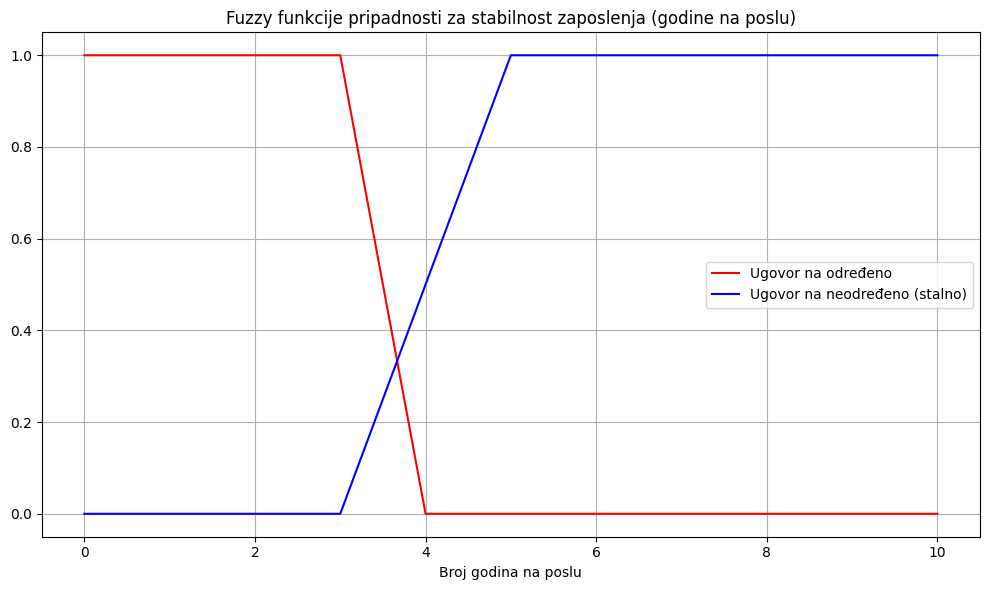

In [ ]:
#Univerzum stabilnost zaposlenja
zaposlenje = ctrl.Antecedent(np.arange(0, 11, 1), 'zaposlenje')

#Funkcije pripadnosti
zaposlenje['odredjeno'] = fuzz.trapmf(zaposlenje.universe, [0, 0, 3, 4])
zaposlenje['stalno'] = fuzz.trapmf(zaposlenje.universe, [3, 5, 10, 10])

# Prikaz grafa
plt.figure(figsize=(10, 6))
plt.plot(zaposlenje.universe, zaposlenje['odredjeno'].mf, label='Ugovor na određeno', color='red')
plt.plot(zaposlenje.universe, zaposlenje['stalno'].mf, label='Ugovor na neodređeno (stalno)', color='blue')
plt.title('Fuzzy funkcije pripadnosti za stabilnost zaposlenja (godine na poslu)')
plt.xlabel('Broj godina na poslu')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###4. Učestalost kašnjenja sa otplatom:

Učestalost kašnjenja sa otplatom možemo definisati kao diskretan broj u opsegu od 0 do 12 (što znači, da ako je mjesečna rata, da klijent kasni čak godinu dana sa otplatom duga).



1. Bez kašnjenja: 0 (ali radi kreiranja fuzzy skupova krećemo se unutar segmenta 0 - 2), dakle puna pripadnost na 0, uz blago opadanja od 1 do 2. => tip funkcije: trapez
2. Povremeno kašnjenje: 1 - 3, dakle raste od 0 do 1, puna pripadnost od 2 do 3, opada do 4. => tip funkcije: trougao
3. Učestalo kašnjenje: 3 - 6+, dakle raste od 3, puna pripadnost od 5 do 12. => tip funkcije: trapez

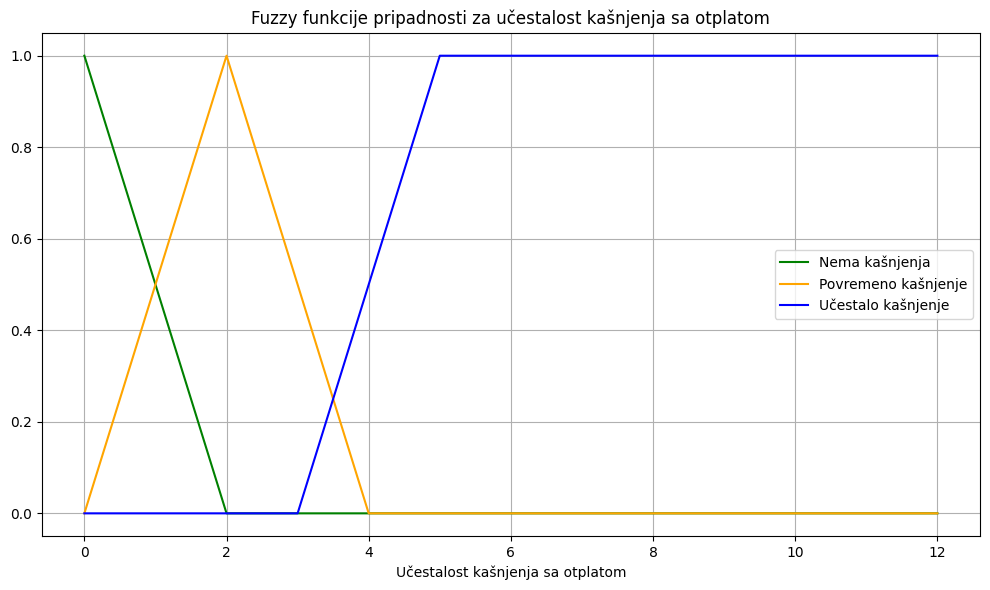

In [ ]:
#Univerzum učestalost kašnjenja sa otplatom
propustene_rate = ctrl.Antecedent(np.arange(0, 13, 1), 'propustene_rate')

#Funkcije pripadnosti
propustene_rate['nema_kasnjenja'] = fuzz.trapmf(propustene_rate.universe, [0, 0, 0, 2])
propustene_rate['povremeno_kasnjenje'] = fuzz.trimf(propustene_rate.universe, [0, 2, 4])
propustene_rate['ucestalo_kasnjenje'] = fuzz.trapmf(propustene_rate.universe, [3, 5, 12, 12])

# Prikaz grafa
plt.figure(figsize=(10, 6))
plt.plot(propustene_rate.universe, propustene_rate['nema_kasnjenja'].mf, label='Nema kašnjenja', color='green')
plt.plot(propustene_rate.universe, propustene_rate['povremeno_kasnjenje'].mf, label='Povremeno kašnjenje', color='orange')
plt.plot(propustene_rate.universe, propustene_rate['ucestalo_kasnjenje'].mf, label='Učestalo kašnjenje', color='blue')
plt.title('Fuzzy funkcije pripadnosti za učestalost kašnjenja sa otplatom')
plt.xlabel('Učestalost kašnjenja sa otplatom')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###5. Štednja:


Ukupni depoziti stanovništva na kraju 2024. godine iznosili su 16,94 milijardi KM, što je povećanje od 1.42 milijarde KM ili 9,2% u odnosu na isti mjesec prethodne godine. Štedni depoziti činili su 31,4% od ukupnih depozita stanovništva, odnosno oko 5,31 milijardi KM. Prosječan iznos štednje po stanovniku BiH iznosio je oko 4.400 KM.

Izvori:

https://6yka.com/ekonomija/statisticki-gledano-svaki-stanovnik-bih-ima-u-prosjeku-ustedeno-4400-km/

https://dnevnibilten.com/centralna-banka-bih-ne-ocekuje-se-znacajniji-pad-kamatnih-stopa/

Na osnovu podataka kreiramo sljedeće fuzzy funkcije pripadnosti.

1. Niska štednja: 0 - 6.000 KM => tip funkcije: trapez
2. Srednja štednja: 5.000 - 25.000 KM => tip funkcije: trougao
3. Visoka štednja: >20.000 KM => tip funkcije: trapez

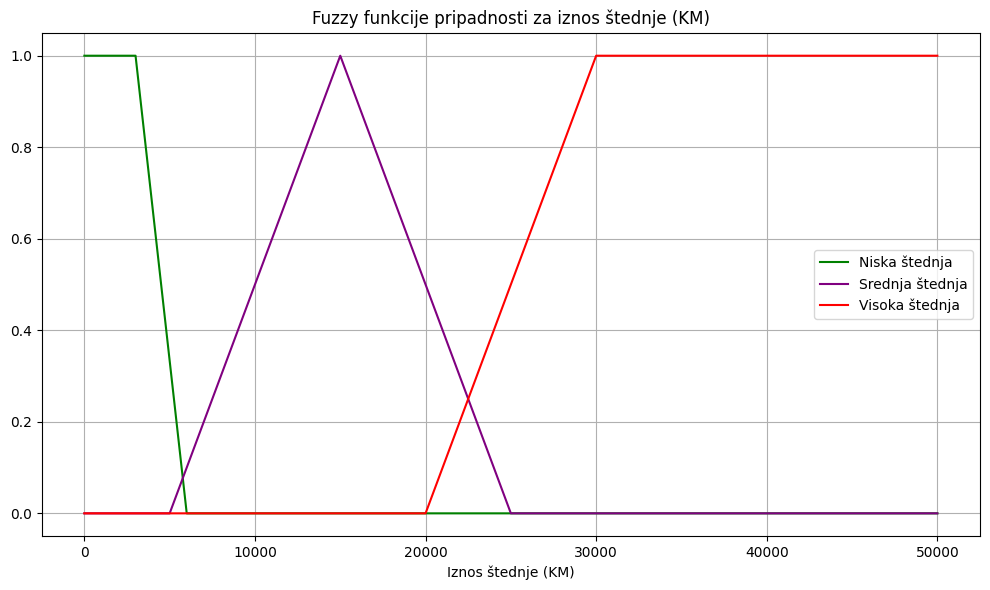

In [ ]:
#Univerzum iznos štednje
stednja = ctrl.Antecedent(np.arange(0, 50001, 100), 'stednja')

#Funkcije pripadnosti
stednja['niska_stednja'] = fuzz.trapmf(stednja.universe, [0, 0, 3000, 6000])
stednja['srednja_stednja'] = fuzz.trimf(stednja.universe, [5000, 15000, 25000])
stednja['visoka_stednja'] = fuzz.trapmf(stednja.universe, [20000, 30000, 50000, 50000])

# Prikaz grafa
plt.figure(figsize=(10, 6))
plt.plot(stednja.universe, stednja['niska_stednja'].mf, label='Niska štednja', color='green')
plt.plot(stednja.universe, stednja['srednja_stednja'].mf, label='Srednja štednja', color='purple')
plt.plot(stednja.universe, stednja['visoka_stednja'].mf, label='Visoka štednja', color='red')
plt.title('Fuzzy funkcije pripadnosti za iznos štednje (KM)')
plt.xlabel('Iznos štednje (KM)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###6. Broj aktivnih kredita:

Broj aktivnih kredita je vrijednost od 0 do (možemo reći najviše) 6.

1. Mali broj aktivnih kredita: 0 - 1 kredita => tip funkcije: trapez
2. Umjeren broj aktvnih kredita: 1 - 3 kredita => tip funkcije: trougao
3. Puno aktivnih kredita: 2.5 - 4.5 kredita => tip funkcije: trapez
4. Ekstremno puno aktivnih kredita: 4 - 6 kredita => tip funkcije: trapez

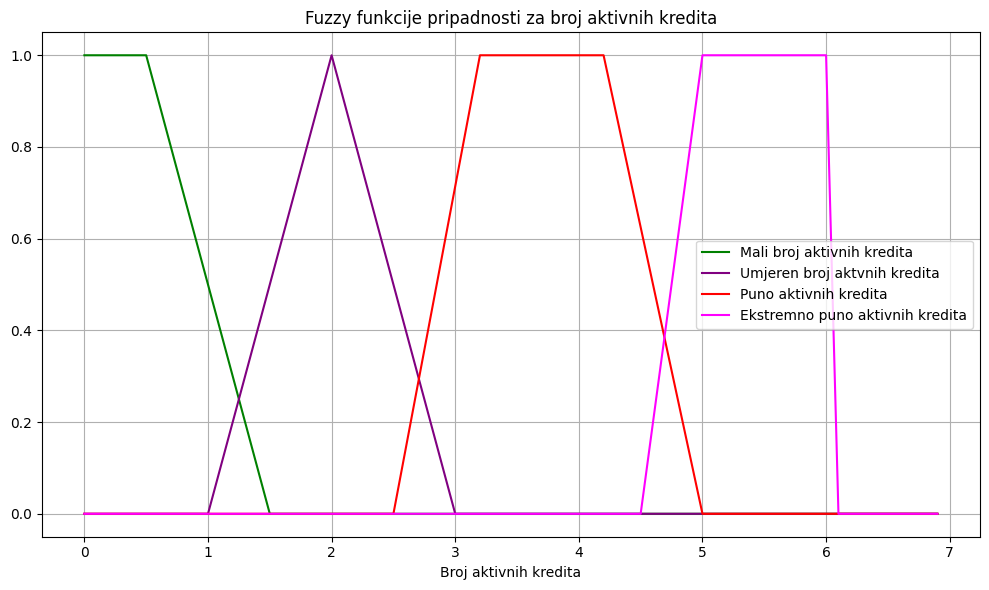

In [ ]:
#Univerzum aktivni krediti
aktivni_krediti = ctrl.Antecedent(np.arange(0, 7, 0.1), 'aktivni_krediti')

#Funkcije pripadnosti
aktivni_krediti['malo'] = fuzz.trapmf(aktivni_krediti.universe, [0, 0, 0.5, 1.5])
aktivni_krediti['umjereno'] = fuzz.trimf(aktivni_krediti.universe, [1, 2, 3])
aktivni_krediti['puno'] = fuzz.trapmf(aktivni_krediti.universe, [2.5, 3.2, 4.2, 5])
aktivni_krediti['ekstremno_puno'] = fuzz.trapmf(aktivni_krediti.universe, [4.5, 5, 6, 6])

# iako se kosi sa intuicijom, jer znamo da je broj kredita diskrena varijabla, ovdje su upotrebljeni decimalni brojevi kako bi se ublazili prelazi.
# u ovom slucaju fuzzy logika moze koristit decimalne brojeve za kreiranje funkcij pripadnosti iako su diskretne varijable u pitanju
# npr. 0.5 do 1.5 – postepeni pad pripadnosti, jer od 1 pa naviše više nije "baš nizak", ali još nije potpuno "srednji"


# Prikaz grafa
plt.figure(figsize=(10, 6))
plt.plot(aktivni_krediti.universe, aktivni_krediti['malo'].mf, label='Mali broj aktivnih kredita', color='green')
plt.plot(aktivni_krediti.universe, aktivni_krediti['umjereno'].mf, label='Umjeren broj aktvnih kredita', color='purple')
plt.plot(aktivni_krediti.universe, aktivni_krediti['puno'].mf, label='Puno aktivnih kredita', color='red')
plt.plot(aktivni_krediti.universe, aktivni_krediti['ekstremno_puno'].mf, label='Ekstremno puno aktivnih kredita', color='magenta')
plt.title('Fuzzy funkcije pripadnosti za broj aktivnih kredita')
plt.xlabel('Broj aktivnih kredita')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###7. Dužina kreditne historije:

Centralni registar kredita (CRK), kojim upravlja Centralna banka BiH, čuva podatke o zatvorenim zaduženjima za posljednih pet godina, što sugeriše da se kreditna aktivnost unutar tog perioda smatra relevantnom za procjenu kreditne sposobnosti klijenta. Zbog nedostatka informacija o konkretnoj podjeli dužine kreditne historije, ograničiti ćemo se na relevantni period od 5 godina.

Izvor:  https://cbbh.ba/Content/Read/1235

1. Kratka kreditna historija: 0 - 2 godine => tip funkcije: trapez
2. Srednja kreditna historija: 2 - 5 godina => tip funkcije: trougao
3. Duga kreditna historija: >5 godina => tip funkcije: trapez

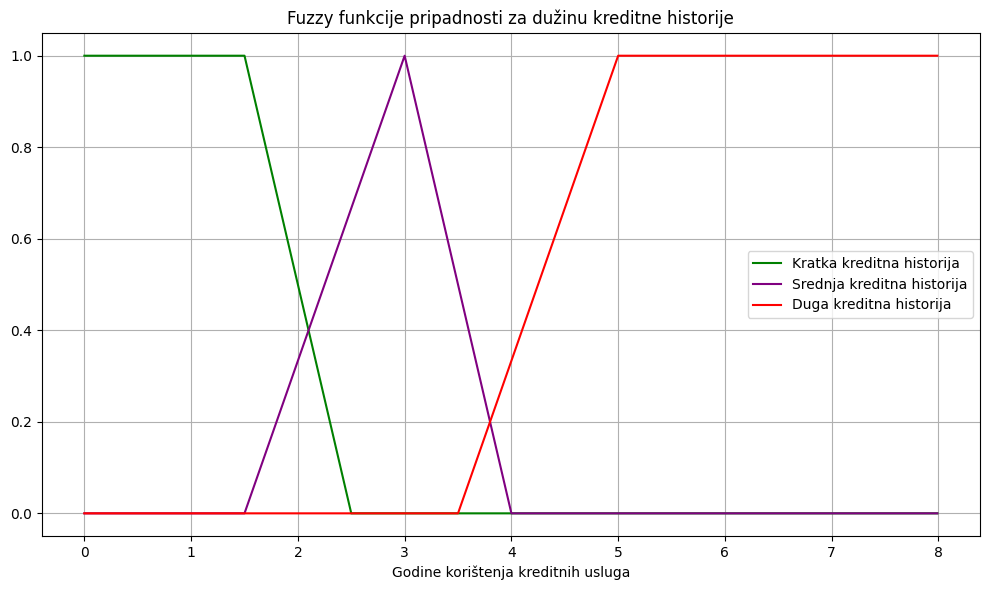

In [ ]:
#Univerzum kreditna historija
kreditna_historija = ctrl.Antecedent(np.arange(0, 8, 0.01), 'kreditna_historija')

#Funkcije pripadnosti
kreditna_historija['kratka'] = fuzz.trapmf(kreditna_historija.universe, [0, 0, 1.5, 2.5])
kreditna_historija['srednja'] = fuzz.trimf(kreditna_historija.universe, [1.5, 3, 4])
kreditna_historija['duga'] = fuzz.trapmf(kreditna_historija.universe, [3.5, 5, 8, 8])

# Prikaz grafa
plt.figure(figsize=(10, 6))
plt.plot(kreditna_historija.universe, kreditna_historija['kratka'].mf, label='Kratka kreditna historija', color='green')
plt.plot(kreditna_historija.universe, kreditna_historija['srednja'].mf, label='Srednja kreditna historija', color='purple')
plt.plot(kreditna_historija.universe, kreditna_historija['duga'].mf, label='Duga kreditna historija', color='red')
plt.title('Fuzzy funkcije pripadnosti za dužinu kreditne historije')
plt.xlabel('Godine korištenja kreditnih usluga')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###IZLAZNA VARIJABLA: Kreditna sposobnost

Kako u BiH ne postoji javno dostupna skala za procjenu kreditne sposobnosti (tačnije CRK nije takvu definisao). Fokusirati ćemo se na druge dostupne skale. FICO (SAD) je standardni sistem bodovanja, skala 300 - 850. VantageScore je alternativa FICO score-a, skala 300 - 850. CRS (EU banke) predstavlja vjerovatnoću uredne otplate kredita, skala 0 - 1. Interni modeli banaka su skale definisane po izboru same banke.

Međutim, u nastavku ćemo koristiti FICO skalu, jer ona prestavlja univerzalni model.

Izvor: https://www.badcredit.org/how-to/credit-score-range/

1. Loša: 300 - 579 => tip funkcije: trapez
2. Umjerena: 580 - 669 => tip funkcije: trougao
3. Dobra: 670 - 739 => tip funkcije: trougao
4. Veoma dobra: 740 - 799 => tip funkcije: trougao
5. Odlična: 800 - 850 => tip funkcije: trapez

<ipython-input-9-65c1e2a1804b>:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


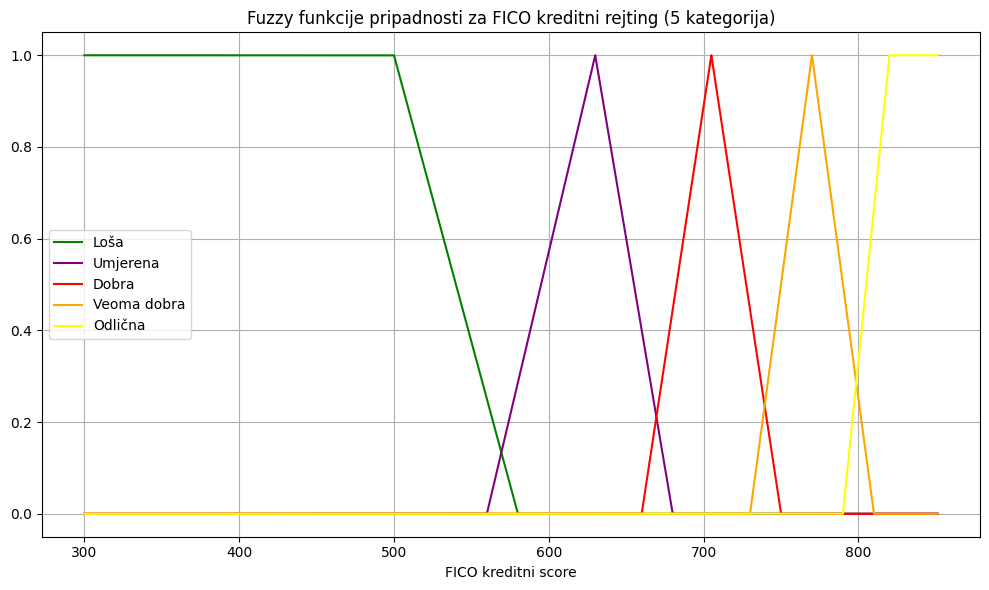

In [ ]:
#Univerzum FICO skala (300 do 850)
fico = ctrl.Consequent(np.arange(300, 851, 0.001), 'FICO_skala')

#Funkcije pripadnosti
fico['losa'] = fuzz.trapmf(fico.universe, [300, 300, 500, 580])
fico['umjerena'] = fuzz.trimf(fico.universe, [560, 630, 680])
fico['dobra'] = fuzz.trimf(fico.universe, [660, 705, 750])
fico['veoma_dobra'] = fuzz.trimf(fico.universe, [730, 770, 810])
fico['odlicna'] = fuzz.trapmf(fico.universe, [790, 820, 851, 851])

# Prikaz grafa
plt.figure(figsize=(10, 6))
plt.plot(fico.universe, fico['losa'].mf, label='Loša', color='green')
plt.plot(fico.universe, fico['umjerena'].mf, label='Umjerena', color='purple')
plt.plot(fico.universe, fico['dobra'].mf, label='Dobra', color='red')
plt.plot(fico.universe, fico['veoma_dobra'].mf, label='Veoma dobra', color='orange')
plt.plot(fico.universe, fico['odlicna'].mf, label='Odlična', color='yellow')
plt.title('Fuzzy funkcije pripadnosti za FICO kreditni rejting (5 kategorija)')
plt.xlabel('FICO kreditni score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#**4. IZRADA I IMPLEMENTACIJA FUZZY PRAVILA:**

1. IF DTI ratio je nizak AND visina prihoda je visoka AND stabilnost zaposlenja je stalno AND učestalost kašnjenja sa otplatom je bez kašnjenja THEN kreditna sposobnost je odlična.

2. IF (DTI ratio je nizak AND visina prihoda je srednja) OR stabilnost zaposlenja je stalno THEN kreditna sposobnost je veoma dobra.

3. IF NOT (visina prihoda je visoka) AND DTI ratio je nizak THEN kreditna sposobnost je umjerena.

4. IF DTI ratio je srednji AND (visina prihoda je visoka OR stabilnost zaposlenja je stalno) THEN kreditna sposobnost je veoma dobra.

5. IF DTI ratio je srednji AND (učestalost kašnjenja sa otplatom je povremeno OR učestalost kašnjenja sa otplatom je učestalo) THEN kreditna sposobnost je umjerena.

6. IF DTI ratio je visok OR učestalost kašnjenja sa otplatom je učestalo THEN kreditna sposobnost je loša.

7. IF DTI ratio je visok AND NOT (visina prihoda je visoka OR visina prihoda je srednja) THEN kreditna sposobnost je loša.

8. IF stabilnost zaposlenja je određeno AND (broj aktivnih kredita je puno OR broj aktivnih kredita je ekstremno puno) THEN kreditna sposobnost je loša.

9. IF štednja je visoka AND (visina prihoda je visoka OR stabilnost zaposlenja je stalno) THEN kreditna sposobnost je odlična.

10. IF štednja je niska AND učestalost kašnjenja sa otplatom je učestalo THEN kreditna sposobnost je loša.

11. IF dužina kreditne historije je duga AND NOT (učestalost kašnjenja sa otplatom je povremeno OR učestalost kašnjenja sa otplatom je učestalo) THEN kreditna sposobnost je odlična.

12. IF dužina kreditne historije je kratka AND (učestalost kašnjenja sa otplatom je povremeno OR učestalost kašnjenja sa otplatom je učestalo) THEN kreditna sposobnost je umjerena.

13. IF broj aktivnih kredita je mali AND DTI ratio je nizak THEN kreditna sposobnost je veoma dobra.

14. IF broj aktivnih kredita je ekstremno puno OR DTI ratio je visok THEN kreditna sposobnost je loša.

15. IF stabilnost zaposlenja je stalno AND štednja je srednja THEN kreditna sposobnost je veoma dobra.

16. IF visina prihoda je srednja AND DTI ratio je visok THEN kreditna sposobnost je umjerena.

17. IF učestalost kašnjenja sa otplatom je bez kašnjenja AND štednja je visoka THEN kreditna sposobnost je veoma dobra.

18. IF visina prihoda je niska AND dužina kreditne historije je kratka THEN kreditna sposobnost je loša.

19. IF broj aktivnih kredita je umjeren AND štednja je srednja THEN kreditna sposobnost je umjerena.

20. IF DTI ratio je nizak AND dužina kreditne historije je duga THEN kreditna sposobnost je odlična.

21. IF stabilnost zaposlenja je određeno AND NOT štednja je visoka THEN kreditna sposobnost je loša.

22. IF učestalost kašnjenja sa otplatom je povremeno AND visina prihoda je srednja THEN kreditna sposobnost je umjerena.

23. IF visina prihoda je visoka AND broj aktivnih kredita je mala THEN kreditna sposobnost je veoma dobra.

24. IF DTI ratio je srednji AND dužina kreditne historije je srednja THEN kreditna sposobnost je umjerena.

25. IF broj aktivnih kredita je puno AND NOT štednja je visoka THEN kreditna sposobnost je loša.

26. IF dužina kreditne historije je duga AND stabilnost zaposlenja je stalno THEN kreditna sposobnost je odlična.

27. IF štednja je srednja AND učestalost kašnjenja sa otplatom je bez kašnjenja THEN kreditna sposobnost je veoma dobra.

28. IF visina prihoda je niska AND broj aktivnih kredita je puno THEN kreditna sposobnost je loša.

29. IF stabilnost zaposlenja je stalno AND DTI ratio je nizak THEN kreditna sposobnost je veoma dobra.

30. IF dužina kreditne historije je kratka AND broj aktivnih kredita je puno THEN kreditna sposobnost je umjerena.






















In [ ]:
rules = []
rules.append(ctrl.Rule(dti['vrlo_nizak'] & prihodi['visoka'] & zaposlenje['stalno'] & propustene_rate['nema_kasnjenja'], fico['odlicna'], label='Pravilo 1'))
rules.append(ctrl.Rule((dti['vrlo_nizak'] & prihodi['srednja']) | zaposlenje['stalno'], fico['veoma_dobra'], label='Pravilo 2'))
rules.append(ctrl.Rule(~prihodi['visoka'] & dti['vrlo_nizak'], fico['umjerena'], label='Pravilo 3'))
rules.append(ctrl.Rule(dti['povecani_rizici'] & (prihodi['visoka'] | zaposlenje['stalno']), fico['veoma_dobra'], label='Pravilo 4'))
rules.append(ctrl.Rule(dti['povecani_rizici'] & (propustene_rate['povremeno_kasnjenje'] | propustene_rate['ucestalo_kasnjenje']), fico['umjerena'], label='Pravilo 5'))
rules.append(ctrl.Rule(dti['kriticno'] | propustene_rate['ucestalo_kasnjenje'], fico['losa'], label='Pravilo 6'))
rules.append(ctrl.Rule(dti['kriticno'] & ~((prihodi['visoka']) | (prihodi['srednja'])), fico['losa'], label='Pravilo 7'))
rules.append(ctrl.Rule(zaposlenje['odredjeno'] & (aktivni_krediti['puno'] | aktivni_krediti['ekstremno_puno']), fico['losa'], label='Pravilo 8'))
rules.append(ctrl.Rule(stednja['visoka_stednja'] & (prihodi['visoka'] | zaposlenje['stalno']), fico['odlicna'], label='Pravilo 9'))
rules.append(ctrl.Rule(stednja['niska_stednja'] & propustene_rate['ucestalo_kasnjenje'], fico['losa'], label='Pravilo 10'))
rules.append(ctrl.Rule(kreditna_historija['duga'] & ~(propustene_rate['povremeno_kasnjenje'] | propustene_rate['ucestalo_kasnjenje']), fico['odlicna'], label='Pravilo 11'))
rules.append(ctrl.Rule(kreditna_historija['kratka'] & (propustene_rate['povremeno_kasnjenje'] | propustene_rate['ucestalo_kasnjenje']), fico['umjerena'], label='Pravilo 12'))
rules.append(ctrl.Rule(aktivni_krediti['malo'] & dti['vrlo_nizak'], fico['veoma_dobra'], label='Pravilo 13'))
rules.append(ctrl.Rule(aktivni_krediti['ekstremno_puno'] | dti['kriticno'], fico['losa'], label='Pravilo 14'))
rules.append(ctrl.Rule(zaposlenje['stalno'] & stednja['srednja_stednja'], fico['veoma_dobra'], label='Pravilo 15'))
rules.append(ctrl.Rule(prihodi['srednja'] & dti['kriticno'], fico['umjerena'], label='Pravilo 16'))
rules.append(ctrl.Rule(propustene_rate['nema_kasnjenja'] & stednja['visoka_stednja'], fico['veoma_dobra'], label='Pravilo 17'))
rules.append(ctrl.Rule(prihodi['niska'] & kreditna_historija['kratka'], fico['losa'], label='Pravilo 18'))
rules.append(ctrl.Rule(aktivni_krediti['umjereno'] & stednja['srednja_stednja'], fico['umjerena'], label='Pravilo 19'))
rules.append(ctrl.Rule(dti['vrlo_nizak'] & kreditna_historija['duga'], fico['odlicna'], label='Pravilo 20'))
rules.append(ctrl.Rule(zaposlenje['odredjeno'] & ~stednja['visoka_stednja'], fico['losa'], label='Pravilo 21'))
rules.append(ctrl.Rule(propustene_rate['povremeno_kasnjenje'] & prihodi['srednja'], fico['umjerena'], label='Pravilo 22'))
rules.append(ctrl.Rule(prihodi['visoka'] & aktivni_krediti['malo'], fico['veoma_dobra'], label='Pravilo 23'))
rules.append(ctrl.Rule(dti['povecani_rizici'] & kreditna_historija['srednja'], fico['umjerena'], label='Pravilo 24'))
rules.append(ctrl.Rule(aktivni_krediti['puno'] & ~stednja['visoka_stednja'], fico['losa'], label='Pravilo 25'))
rules.append(ctrl.Rule(kreditna_historija['duga'] & zaposlenje['stalno'], fico['odlicna'], label='Pravilo 26'))
rules.append(ctrl.Rule(stednja['srednja_stednja'] & propustene_rate['nema_kasnjenja'], fico['veoma_dobra'], label='Pravilo 27'))
rules.append(ctrl.Rule(prihodi['niska'] & aktivni_krediti['puno'], fico['losa'], label='Pravilo 28'))
rules.append(ctrl.Rule(zaposlenje['stalno'] & dti['vrlo_nizak'], fico['veoma_dobra'], label='Pravilo 29'))
rules.append(ctrl.Rule(kreditna_historija['kratka'] & aktivni_krediti['puno'], fico['umjerena'], label='Pravilo 30'))

Prethodna pravila su kreirana na osnovu sljedećih općih finansijskih pravila i praksi:
1. Nizak odnos duga i prihoda implicira niži rizik, tačnije pozitivnu kreditnu sposobnost.
2. Visok prihod implicira bolju platežnu moć, tačnije veću kreditnu sposobnost.
3. Stalno zaposlenje implicira stabilnost mogućnosti redovne otplate, tačnije povećava vjerovatnoću uredne otplate.
4. Učestala kašnjenja otplate rata u prethodnom peoridu imaju negativnu konotaciju, smanjuje kreditni rejting, odnoso direktno smanjuje kreditnu sposobnost klijenta.
5. Duga kreditna historija bez kašnjenja sa otplatama duga, pokazuje odgovornost klijenta i povećva klijentovu kreditnu sposobonost.

Izvori:

https://www.capitalone.com/learn-grow/money-management/five-cs-of-credit/

https://www.investopedia.com/terms/f/five-c-credit.asp

https://www.capitalone.com/learn-grow/money-management/what-is-credit-history/

Ovi linkovi ne sadrže informacije o uticaju stabilnosti zaposlenja na kreditni rejting, ali je bilo prilično intuitivno, stoga smo sami donijeli odluku u uticaju tog parametra na izlaznu varijablu.

#**5. PRIKAZ REZULTATA:**

Prikaz rezultat ćemo izvršiti preko ulaza/izlaza:

In [ ]:
kredit_ctrl = ctrl.ControlSystem(rules)
kredit_simulacija = ctrl.ControlSystemSimulation(kredit_ctrl)


U okviru biblioteke skfuzzy, objekti ControlSystem i ControlSystemSimulation ključni su za izvođenje procjene (inferencije) na osnovu ulaznih vrijednosti.



*   ControlSystem predstavlja skup definisanih pravila (rules) i upravlja logikom zaključivanja. On služi za kombinovanje svih pravila unutar jednog fuzzy sistema.
*   ControlSystemSimulation koristi pravila definisana u ControlSystem objektu, uz konkretne vrijednosti ulaznih varijabli. Na osnovu toga aktivira odgovarajuća pravila i vrši fuzzy inferenciju, uključujući i defuzzifikaciju.

Važno je napomenuti da skfuzzy podrazumijevano koristi Mamdani metod inferencije (procesa zaključivanja). Ovaj metod:

* koristi minimum (min) funkciju za implikaciju pravila,
* koristi maksimum (max) za agregaciju izlaza svih pravila,
* a defuzzifikaciju najčešće vrši pomoću centroid metode (težište površine).

U dijelu ispod kreiramo funkciju kao bismo lakše mogli testirati naredne testne slučajeve i kako ne bismo morali ponavljati iste dijelove koda.

Funkcija ispisuje ulazne varijable i njihove brojčane vrijednosti, potom računa izlaznu varijablu (FICO score) te je ispisuje. Zatim na ekran iscrtava grafove pripadnosti za svaki ulaz i na kraju za izlaznu varijablu. Aktivna pravila nisu prikazana, jer uključene biblioteke ne podržavaju funkcije koje nam daju podatke o tome koja su pravila aktivna i koliko. Međutim, moguće je implementirati funkciju koja bi rješavala taj problem, ali to nije neophodno, jer i sami intuitivno možemo zaključiti koja su pravila aktivna.

Također, bitno je naglasiti da podaci koje testiramo su fiktivni, jer nemamo pristup stvarnim podacima o klijentima kojima je kredit odobren ili koji još uvijek čekaju odobravanje. Dakle, podaci koji se koriste u nastavku su čisto upotrijebljeni u testne svrhe.

In [ ]:
def test_kredit(dti_vr, prihod_vr, zaposlenje_vr, rate_vr, stednja_vr, aktivnost_vr, historija_vr):
  kredit_simulacija.input['dti_ratio'] = dti_vr
  kredit_simulacija.input['prihodi'] = prihod_vr
  kredit_simulacija.input['zaposlenje'] = zaposlenje_vr
  kredit_simulacija.input['propustene_rate'] = rate_vr
  kredit_simulacija.input['stednja'] = stednja_vr
  kredit_simulacija.input['aktivni_krediti'] = aktivnost_vr
  kredit_simulacija.input['kreditna_historija'] = historija_vr
  kredit_simulacija.compute()
  print(f"Ulazi: DTI={dti_vr}, Prihodi={prihod_vr}, Zaposlenje={zaposlenje_vr}, "
          f"Propustene rate={rate_vr}, Stednja={stednja_vr}, "
          f"Aktivni krediti={aktivnost_vr}, Kreditna historija={historija_vr}")
  print(f"Rezultat (FICO skor): {kredit_simulacija.output['FICO_skala']:.2f}")
  dti.view(sim=kredit_simulacija)
  prihodi.view(sim=kredit_simulacija)
  zaposlenje.view(sim=kredit_simulacija)
  propustene_rate.view(sim=kredit_simulacija)
  stednja.view(sim=kredit_simulacija)
  aktivni_krediti.view(sim=kredit_simulacija)
  kreditna_historija.view(sim=kredit_simulacija)
  fico.view(sim=kredit_simulacija)
  plt.show()

##**Test 1:**

Ulazi: DTI=5, Prihodi=5000, Zaposlenje=8, Propustene rate=0, Stednja=30000, Aktivni krediti=1, Kreditna historija=6
Rezultat (FICO skor): 800.62


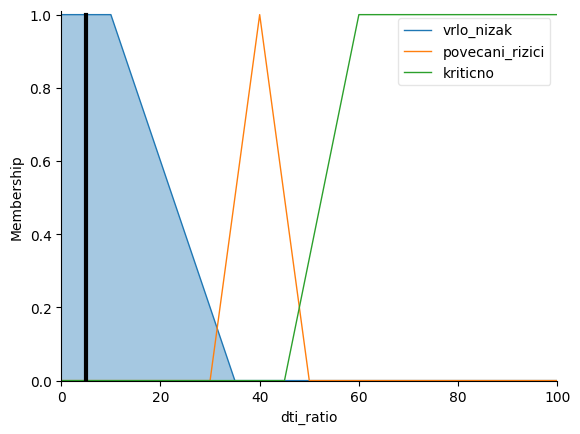

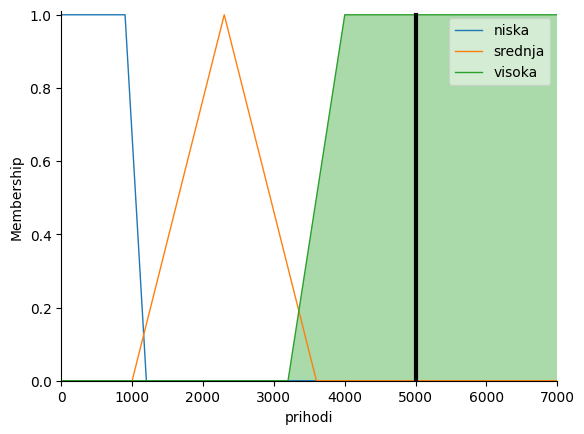

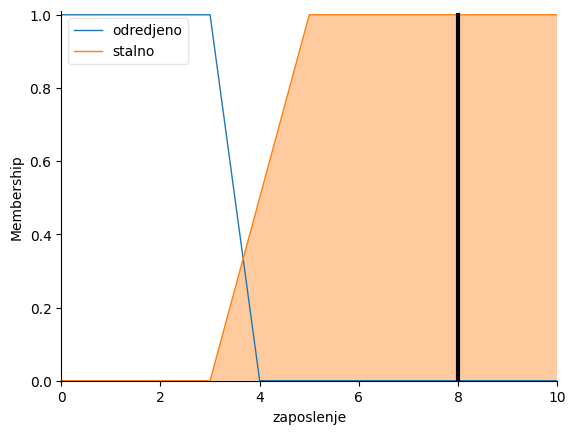

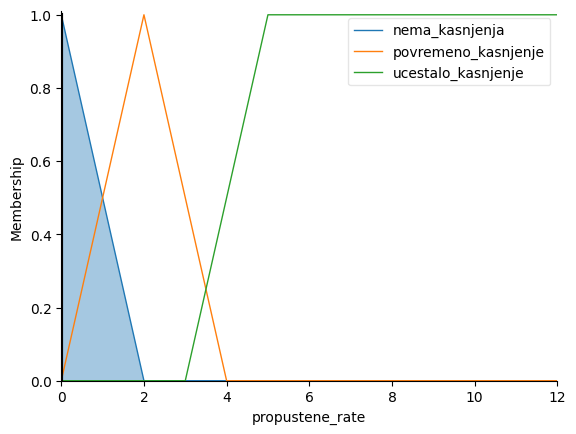

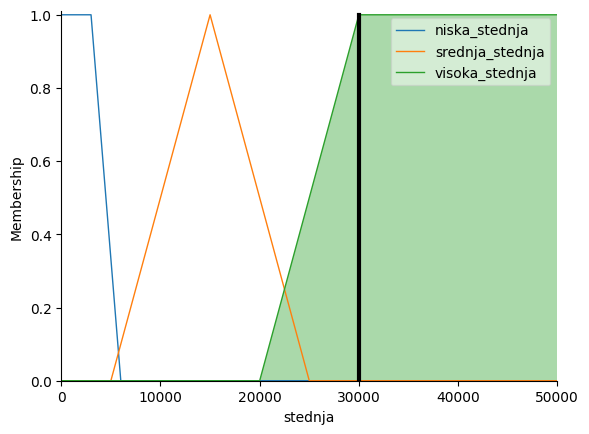

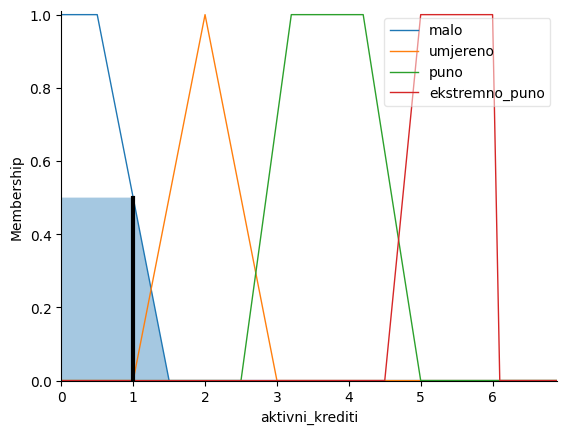

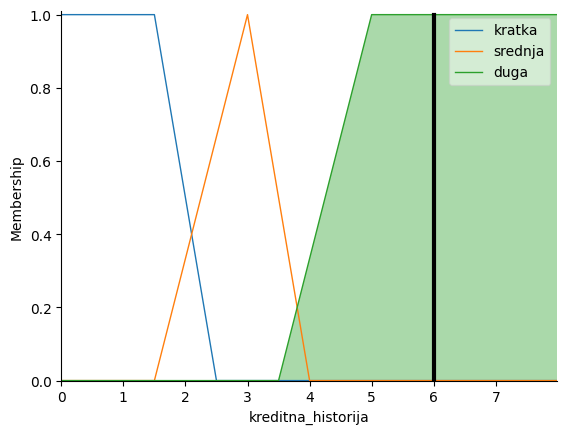

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


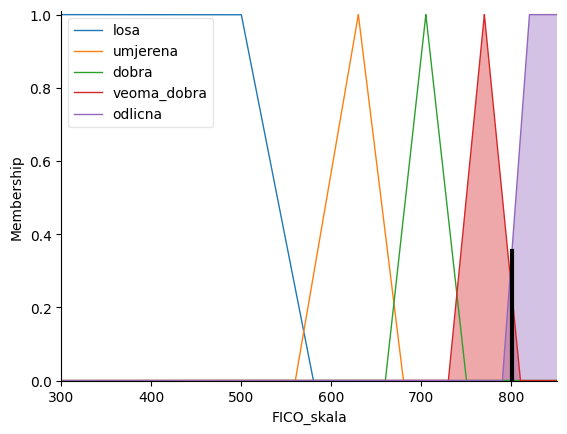

In [ ]:
test_kredit(5, 5000, 8, 0, 30000, 1, 6)

**Osvrt na rezultate testa:**

Na osnovu unesenih parametara znamo sljedeće:

1. DTI (odnos duga i prihoda): 5% — veoma nizak.
2. Visina prihoda: 5000 KM — visoki mjesečni prihodi, koji omogućavaju sigurnu otplatu kreditnih obaveza.
3. Stabilnost zaposlenja: 8 godina (stabilno zaposlenje) — ukazuje na dugoročni izvor prihoda.
4. Učestalost kašnjenja sa otplatom: 0 — nema evidentiranih kašnjenja u otplati.
5. Štednja: 30000 — visok iznos štednje, pruža dodatnu finansijsku sigurnost.
6. Broj aktivnih kredita: 1 — mali broj kreditnih obaveza.
7. Dužina kreditne historije: 6 godina — duga i pouzdana kreditna historija.

**Dobijeni FICO skor: 800.62**

Ovaj rezultat spada u kategoriju odličnih kreditnih rejtinga, što znači da je klijent procenjen kao izuzetno pouzdan.

##**Test 2:**

Ulazi: DTI=30, Prihodi=2300, Zaposlenje=5, Propustene rate=2, Stednja=6000, Aktivni krediti=2.8, Kreditna historija=3.8
Rezultat (FICO skor): 560.63


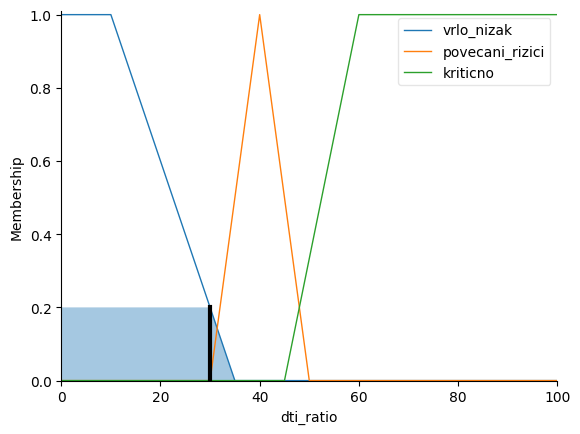

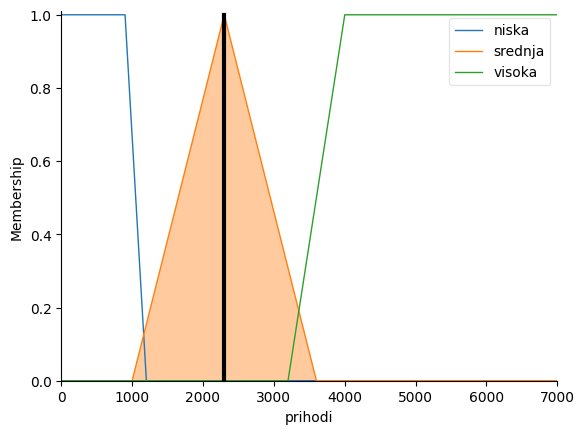

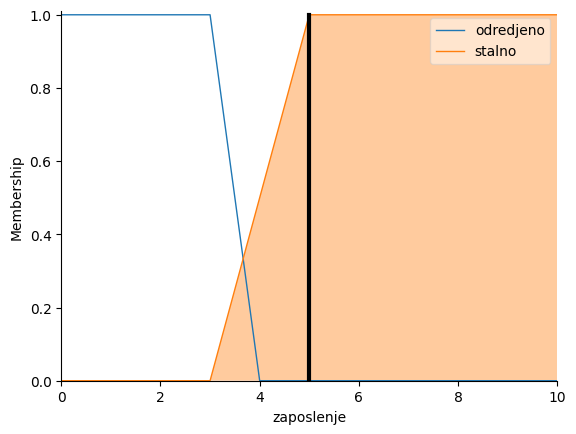

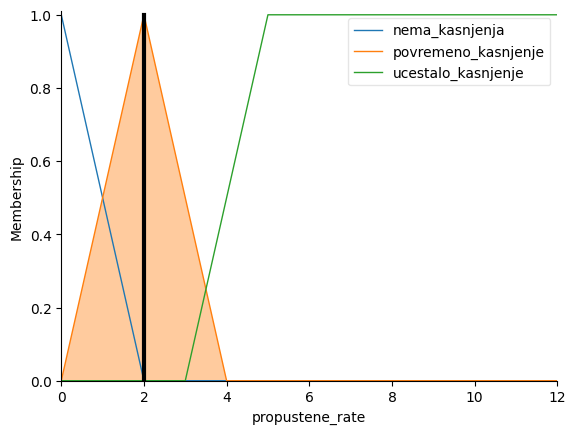

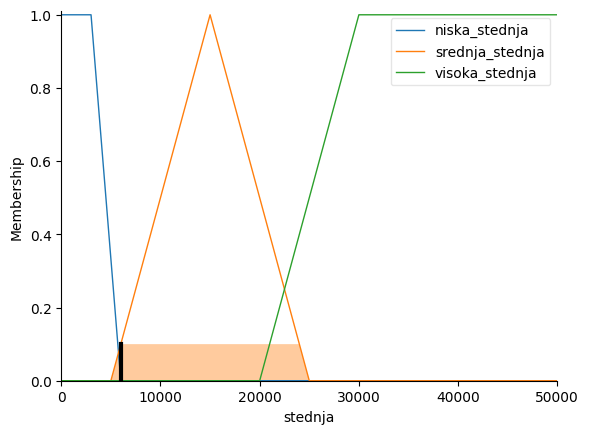

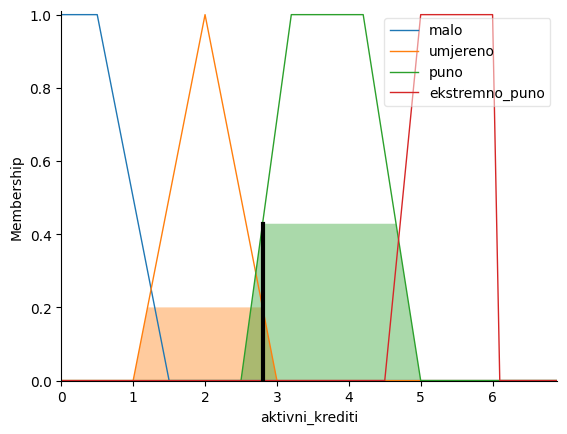

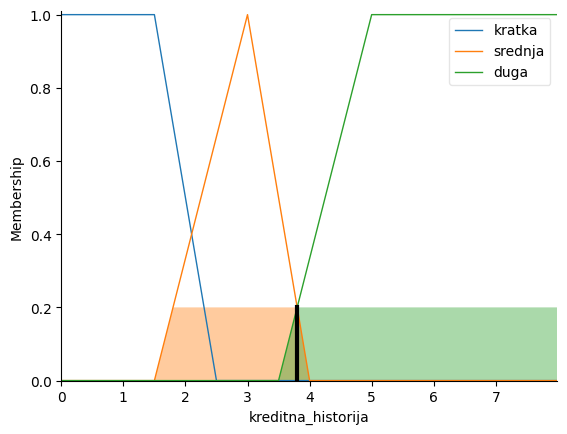

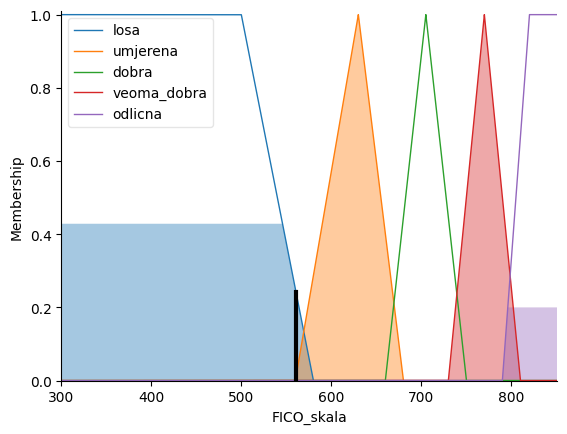

In [ ]:
test_kredit(30, 2300, 5, 2, 6000, 2.8, 3.8)

**Osvrt na rezultate testa:**

Na osnovu unesenih parametara znamo sljedeće:
1. DTI (odnos duga i prihoda): 30% — povećan rizik.
2. Visina prihoda: 2300 KM — srednji nivo prihoda, koji može podržati otplatu, ali sa ograničenjima.
3. Stabilnost zaposlenja: 5 godina — zaposlenje je stabilno.
4. Učestalost kašnjenja sa otplatom: 2 — povremena kašnjenja u otplati, što ukazuje na određene probleme sa odgovornošću.
5. Štednja: 6000 KM — srednji nivo štednje, pruža određenu finansijsku podršku, ali nije dovoljno da značajno smanji rizik.
6. Broj Aktivnih kredita: 2.8 — prilično veliki broj aktivnih kredita.
7. Dužina kreditne historije: 3.8 — srednja dužina kreditne historije.

**Dobijeni FICO skor: 560.63**

Ovaj rezultat spada u kategoriju niske do umjerene kreditne sposobnosti, što ukazuje na značajniji rizik od nemogućnosti otplate. Kreditni score sugeriše da bi odobravanje ovog kredita moglo biti opasno, te da se može odobriti uz postavljanje dodatnih uslova ili zahtjev za kolateral.

##**Test 3:**

Ulazi: DTI=45, Prihodi=3000, Zaposlenje=4, Propustene rate=3, Stednja=5000, Aktivni krediti=3.5, Kreditna historija=2
Rezultat (FICO skor): 482.70


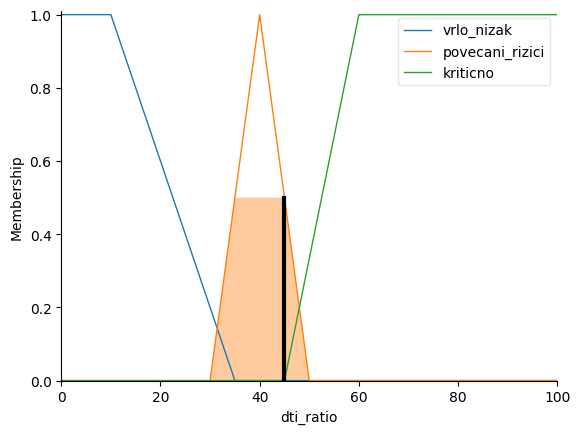

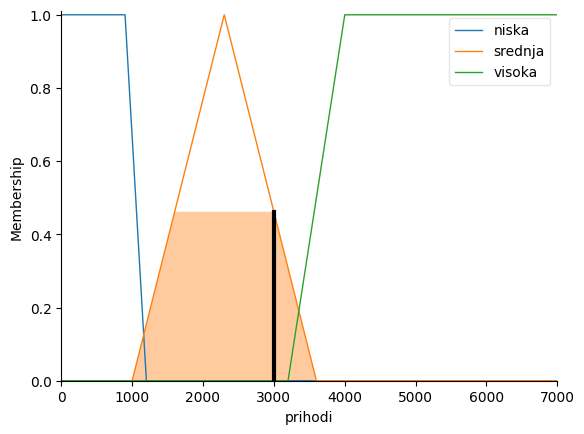

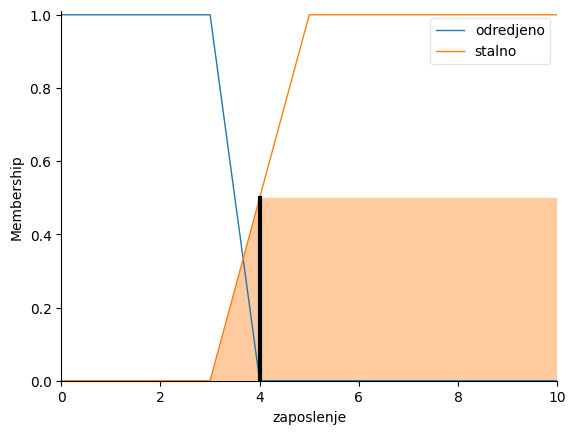

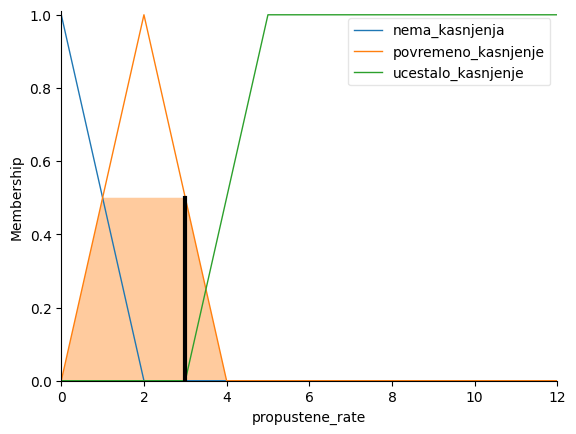

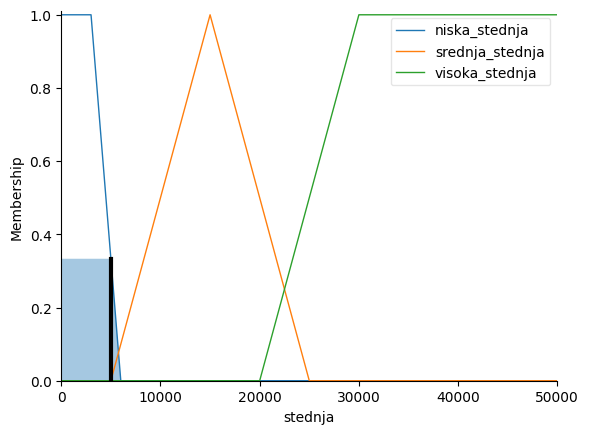

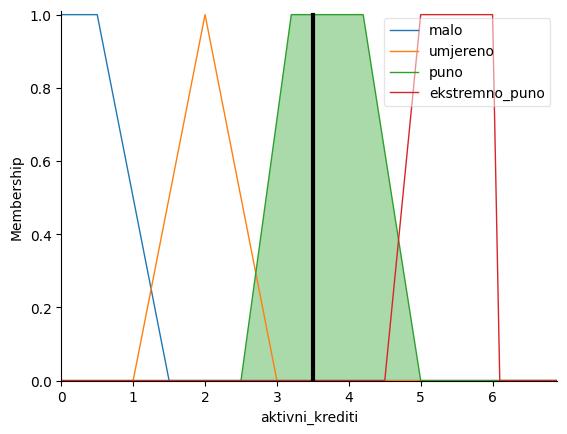

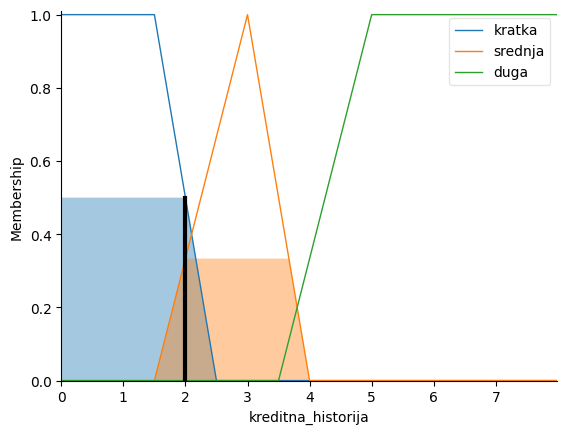

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


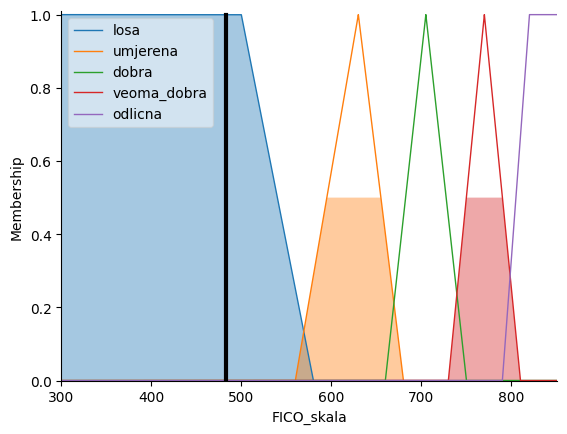

In [ ]:
test_kredit(45, 3000, 4, 3, 5000, 3.5, 2)

**Osvrt na rezultate testa:**

Na osnovu unesenih parametara znamo sljedeće:
1. DTI (odnos duga i prihoda): 45% — srednje visok nivo zaduženosti, što predstavlja rizik za redovnu otplatu.
2. Visina prihoda: 3000 KM — srednji prihod.
3. Stabilnost zaposlenja: 4 godine — zaposlenje je relativno stabilno.
4. Učestalost kašnjenja sa otplatom: 3 — srednje do učestala kašnjenja u otplati, što ukazuje na probleme.
5. Štednja: 5000 KM — niska štednja, koja ne pruža adekvatnu sigurnost.
6. Broj aktivnih kredita: 3.5 — veliki broj aktivnih kredita što dodatno opterećuje finansije.
7. Dužina kreditne historije: 2 — kraća kreditna historija.

**Dobijeni FICO skor: 482.70**

Ovaj rezultat spada u kategoriju lošeg kreditnog rejtinga, što ukazuje na visok rizik od neotplate kredita.

##**Test 4:**

Ulazi: DTI=25, Prihodi=3500, Zaposlenje=6, Propustene rate=1, Stednja=10000, Aktivni krediti=2, Kreditna historija=4
Rezultat (FICO skor): 715.30


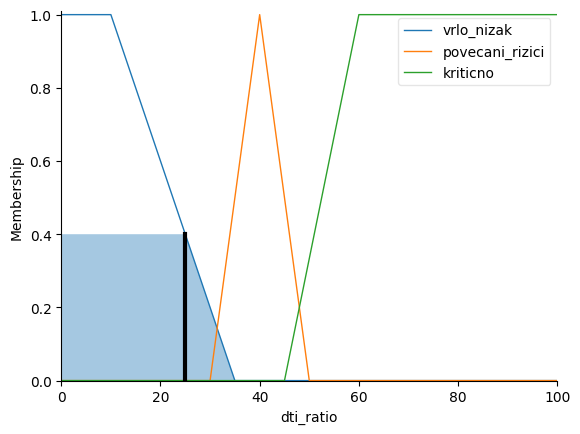

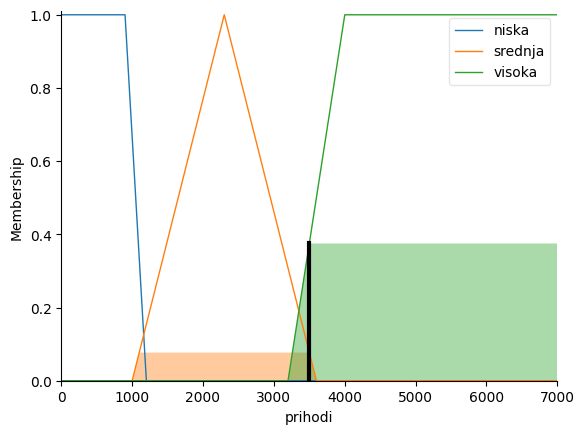

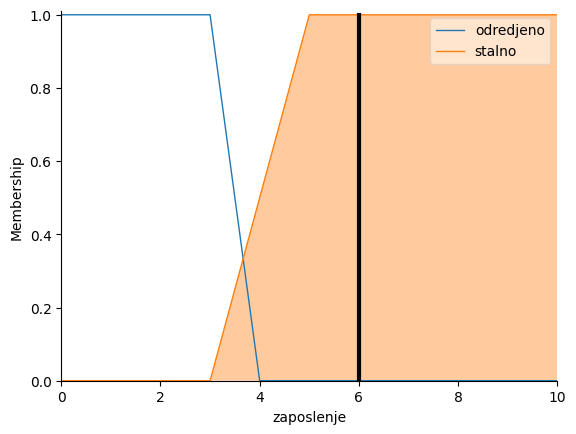

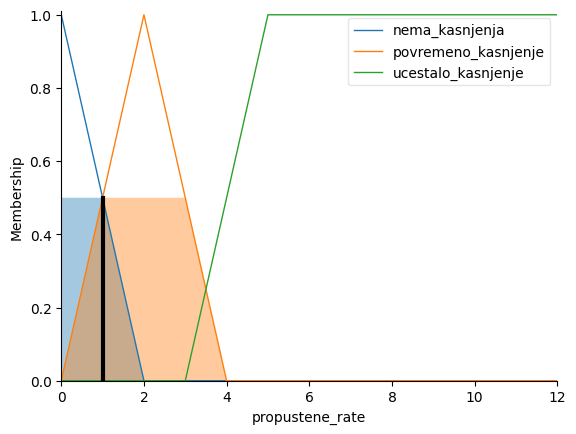

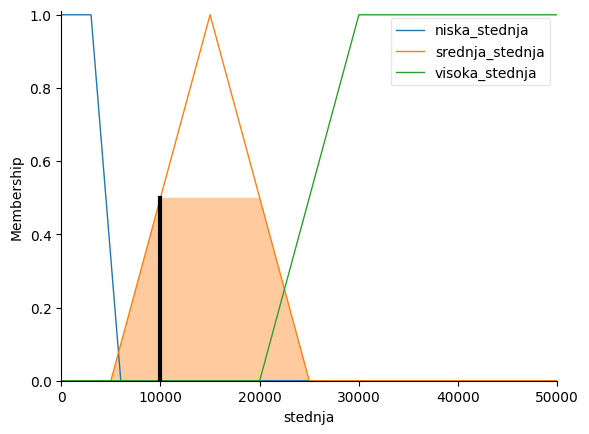

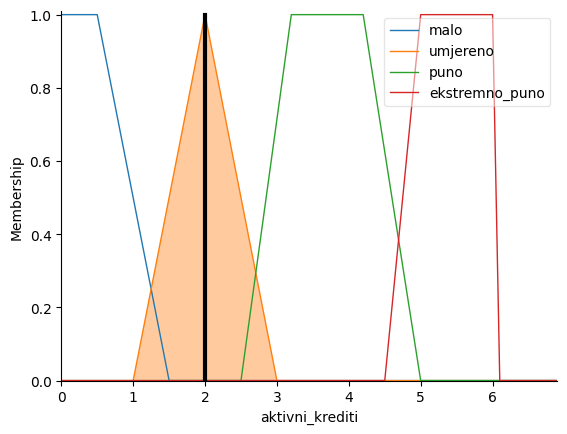

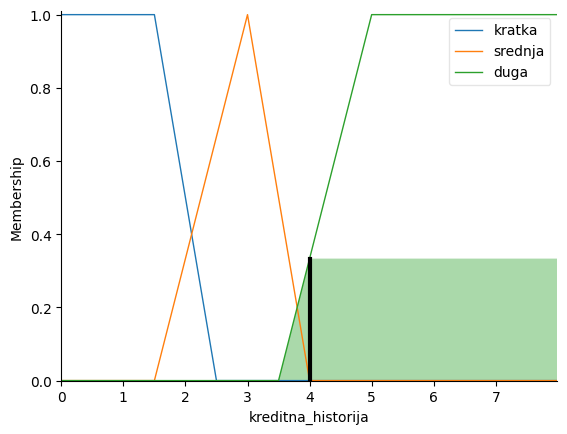

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


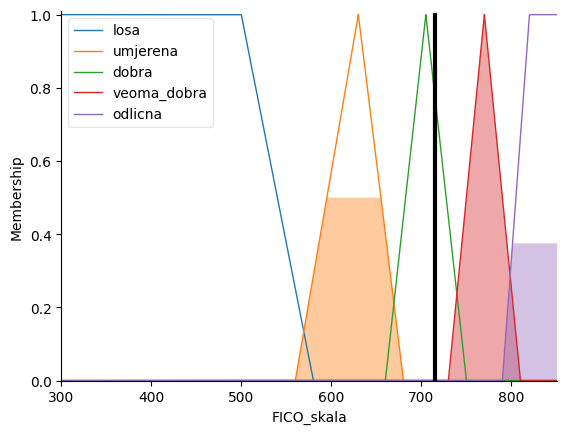

In [ ]:
test_kredit(25, 3500, 6, 1, 10000, 2, 4)

**Osvrt na rezultate testa:**

Na osnovu unesenih parametara znamo sljedeće:
1. DTI (odnos duga i prihoda): 25% — umjereno nizak nivo zaduženosti, što pokazuje da kreditna opterećenja nisu prevelika u odnosu na prihode.
2. Visina prihoda: 3500 KM — više nego srednji nivo prihoda, koji može podržati redovne otplate.
3. Stabilnost zaposlenja: 6 godina — zaposlenje je stabilno, što daje dodatnu sigurnost.
4. Učestalost kašnjenja sa otplatom: 1 — povremena kašnjenja, ali ne često.
5. Štednja: 10000 — srednja štednja, koja može služiti kao finansijska rezerva.
6. Broj aktivnih kredita: 2 — umjereni broj aktivnih kredita.
7. Dužina kreditne historije: 4 — srednje duga kreditna historija, koja doprinosi pozitivnom kredibilitetu.

**Dobijeni FICO skor: 715.30**

Ovaj skor spada u kategoriju dobre kreditne sposobnosti, što znači da je osoba kreditno sposobna, pouzdana i da može dobiti povoljnije uslove kredita.

##**Test 5:**

Ulazi: DTI=35, Prihodi=3200, Zaposlenje=4, Propustene rate=2, Stednja=6000, Aktivni krediti=1.5, Kreditna historija=2.5
Rezultat (FICO skor): 681.33


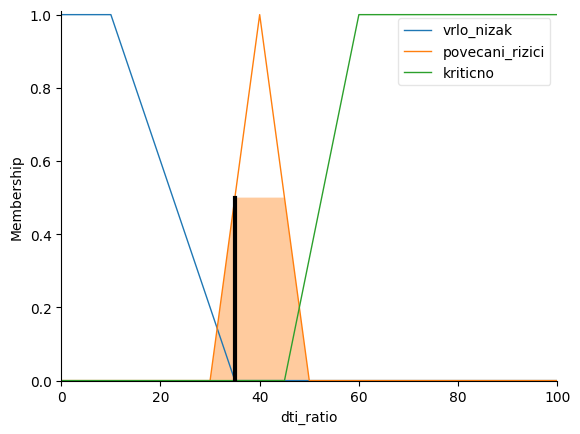

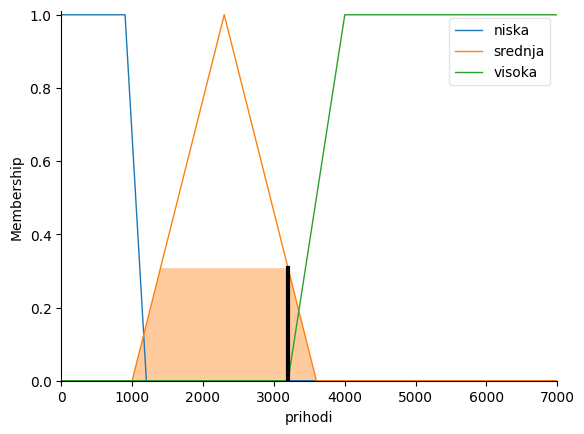

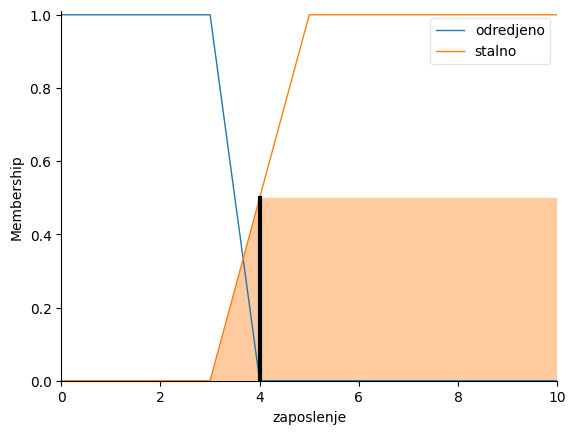

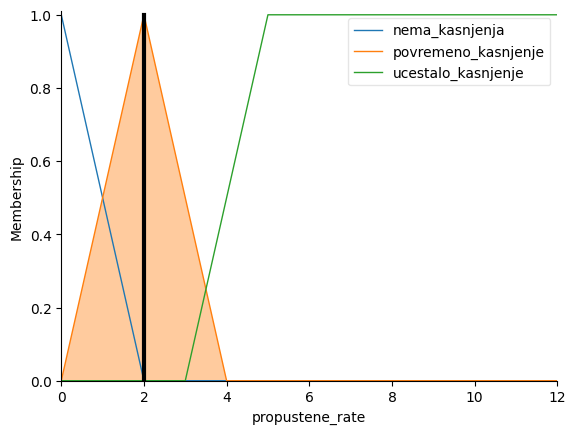

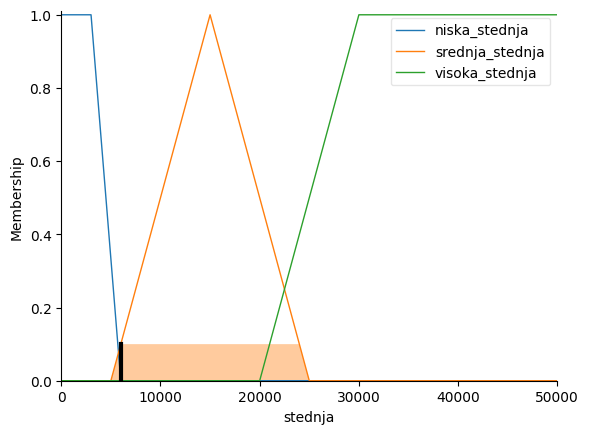

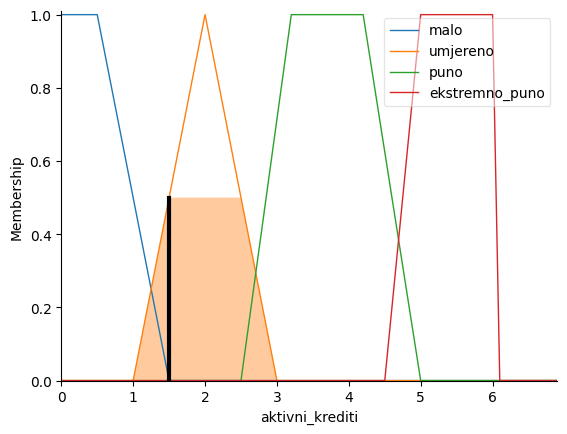

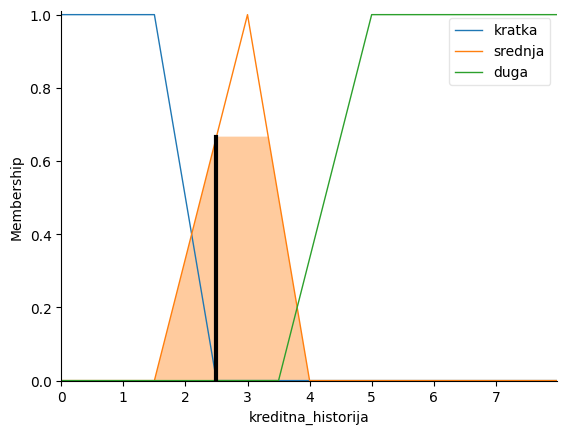

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


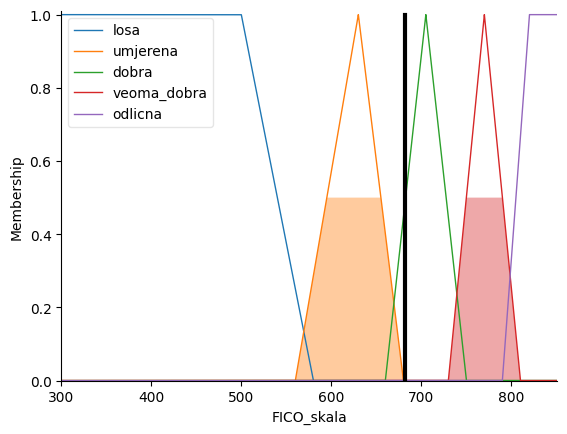

In [ ]:
test_kredit(35, 3200, 4, 2, 6000, 1.5, 2.5)

**Osvrt na rezultate testa:**

Na osnovu unesenih parametara znamo sljedeće:
1. DTI (odnos duga i prihoda): 35% — umjeren nivo zaduženosti, ukazuje na potencijalni rizik.
2. Visina prihoda: 3200 KM — prihodi su u gornjoj granici srednjih.
3. Stabilnost zaposlenja: 4 godine — zaposlenje je na granici sa stalnim, što smanjuje kreditnu stabilnost.
4. Učestalost kašnjenja sa otplatom: 2 — povremena kašnjenja, što može negativno uticati na kreditnu ocjenu.
5. Štednja: 6000 KM — niska do srednja štednja, koja daje nešto sigurnosti, ali ne i znatnu finansijsku rezervu.
6. Broj aktivnih kredita: 1.5 — manji broj aktivnih kredita, što je pozitivan faktor.
7. Dužina kreditne historije: 2.5 — kratka do srednje duga historija.

**Dobijeni FICO skor: 681.33**

Ovaj skor spada u kategoriju umjerene kreditne sposobnosti (dobra). Znači da postoji normalna mogućnost odobrenja kredita, ali uslovi mogu biti manje povoljni nego kod viših skorova.

Vođeni logikom i subjektivnim razumijevanjem problematike testovi imaju smisla, međutim jako je teško provjeriti FICO score, iz sljedećih razloga: paramtri koje koristimo se ne poklapaju u potpunosti sa paramterima koji ulaze u izračun FICO score-a, FICO score je procentualno definisan. Dakle, historija plaćanja 35%, iznos duga 30%, dužina kreditne historije 15%, novi krediti 10%, vrste kredita 10%. Što znači da proračun FICO score-a uzima u obir gore navedene procente, što naš fuzzy kontroler ne radi.

FICO skala je odabrana kao univerzalna skala kreditne sposobnosti i tako definisana nema nikakve veze sa proračunom FICO score-a.

Ako bismo koristi online dostupne kalkulatore FICO score-a ne bismo u potpunosti mogli popuniti ulazne paramtere koje ti testovi zahtjevaju.

Link za FICO score kalkulator: https://www.myfico.com/fico-credit-score-estimator/estimator

kao na primjer na osnovu naših ulaznih parametara nemamo informaciju da li je klijent koristik ostalih usluga banke, koja je vrsta kredita koju klijent zahtijeva, koji je raspoloživi balans na kartici (ako je klijent uopće posjeduje).

Stoga, na osnovu prethodno rečenog ne možemo u potpunosti provjeriti tačnost testova, ali na osnovu znanja koje smo stekli tokom izrade projekta možemo logički zaključiti da su intervali na kojima se nalaze FICO score-ovi ispravni.

Kao što smo u uvodu rekli svaka banka definiše svoje ulazne parametre, skalu i kriterije na osnovu kojih procjenjuje kreditnu sposobnost, jer ne postoji univerzalno definisan način procjene kreditne sposobnosti. Po uzoru na to smo i mi kreirali fuzzy kontroler. Ulazni paramteri koje smo definisali i FICO skala koju smo koristi u sklupu funckija pripadnosti izlazne varijable nemaju nikakvu povezanost sa izračunom FICO score-a.

#**6. ZAKLJUČAK I KRATKA REFLEKSIJA:**

U ovom radu razvijen je fuzzy sistem za procjenu kreditne sposobnosti klijenata, na osnovu više faktora: DTI ratio (odnos duga i prihoda), visina prihoda, stabilnost zaposlenja, učestalost klijentovog kašenjenja sa otplatom, iznos ušteđenog novca, broju aktivih kredita, dužini kreditne historije (odnosno koliko dugo klijent koristi kreditne usluge). Cilj implementiranog sistema je približiti koncept procjene kreditnog rejtinga putem fuzzy logike - metode koja omogućava rad sa nepreciznim i subjektivnim podacima, kakvi se često i javljaju u raznim finansijskim procjenama.

Implementirani sistem predstavlja konceptualni primjer, s obzirom na to da ne postoji uniformno definisani način na koji se procjenuje kreditna sposobnost - svaka banka ili neka druga finansijska institucija razvija vlastite modele i kriterije procjene kreditne sposobnosti klijenta, koji nisu javno dostupni. Pri dizajnu sistema uzete su u obzir granice koje su okvirno usklađene s praksom u Bosni i Hercegovini - npr. visina prosječne plate, godine radnog staža potrebne za stalno zaposlenje, vremenski okvir u kojem CRK (Centralni registar kredita) čuva podatke o zaduženjima. Kao izlazna skala odabrana FICO skala, međunardno poznat model kreditnog scoreing-a, iako nije direktno primjenjiv u BiH, s obzirom na veliki broj banaka sa sopstvenom internom skalom.

Važno je naglasiti da su testni primjeri fiktivni, nisu zasnovani na stvarnim korisničkim podacima, budući da takvi podaci nisu javno dostupni iz zakonskih razloga. U skladu sa prethodno iznesenim činjenicama zaključujemo da ima prostora za unapređenje sistema u dogovoru sa stručnjacima iz date oblasti.



###Raspodjela zadataka:

Svaki član tima je podjednako učestvovao u izradi svih dijelova istraživanja i implementacije. Zbog uniformnosti i međusobne povezanosti dijelova, bilo je teško podijeliti članove tima tako da svaki član radi zasebno. Stoga, smo svi zajedno, timski, radili na izradi cjelokupnog sistema.  